In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import os
import io
from collections import Counter
from sklearn import feature_extraction,model_selection,naive_bayes,metrics,svm
from IPython.display import Image

import warnings
warnings.filterwarnings("ignore")

In [4]:
sms_data = pd.read_csv("sms.csv",usecols = [0,1])
sms_data

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will �_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
sms_data.shape

(5572, 2)

In [6]:
sms_data.isnull().sum()

Label      0
Message    0
dtype: int64

In [7]:
sms_data.duplicated().sum()

403

In [8]:
# Droping the duplicates
sms_data.drop_duplicates(inplace= True)
sms_data.reset_index(drop = True,inplace = True)
sms_data.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
sms_data.duplicated().sum()

0

In [10]:
sms_data.shape

(5169, 2)

In [11]:
sms_data['Label'].value_counts()

Label
ham     4516
spam     653
Name: count, dtype: int64

#### Its shows it is imblance dataset

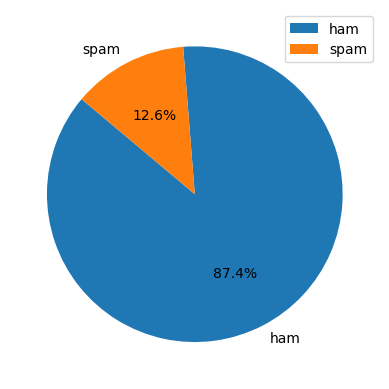

In [12]:

plt.pie(sms_data["Label"].value_counts(),labels = ["ham","spam"],autopct = '%1.1f%%',startangle = 140)
plt.legend()
plt.show()

In [13]:
email_data = pd.read_csv("emails.csv",usecols = [1,2])
email_data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\nth...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\nthis deal is to ...


In [14]:
email_data.shape

(5171, 2)

In [15]:
email_data['Label'].value_counts()

Label
ham     3672
spam    1499
Name: count, dtype: int64

In [16]:
email_data.isna().sum()

Label      0
Message    0
dtype: int64

In [17]:
email_data.duplicated().sum()

178

In [18]:
email_data.drop_duplicates(inplace = True)
email_data.reset_index(drop = True,inplace = True)
email_data.duplicated().sum()

0

In [19]:
final_data = pd.concat([email_data,sms_data],axis = 0 , ignore_index = True)
final_data

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\nth...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\nthis deal is to ...
...,...,...
10157,spam,This is the 2nd time we have tried 2 contact u...
10158,ham,Will �_ b going to esplanade fr home?
10159,ham,"Pity, * was in mood for that. So...any other s..."
10160,ham,The guy did some bitching but I acted like i'd...


In [20]:
final_data.shape

(10162, 2)

In [21]:
final_data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\nth...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\nthis deal is to ...


In [22]:
final_data.tail()

,Label,Message
10157,spam,This is the 2nd time we have tried 2 contact u...
10158,ham,Will �_ b going to esplanade fr home?
10159,ham,"Pity, * was in mood for that. So...any other s..."
10160,ham,The guy did some bitching but I acted like i'd...
10161,ham,Rofl. Its true to its name


In [23]:
final_data.shape

(10162, 2)

In [24]:
final_data.isna().sum()

Label      0
Message    0
dtype: int64

- There is no null value in our dataset.

In [25]:
final_data.to_csv('spamham.csv',index = False)

In [26]:
data = pd.read_csv("spamham.csv")
data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\nth...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\nthis deal is to ...


In [27]:
data.shape


(10162, 2)

### Distribution spam/non-spam plots

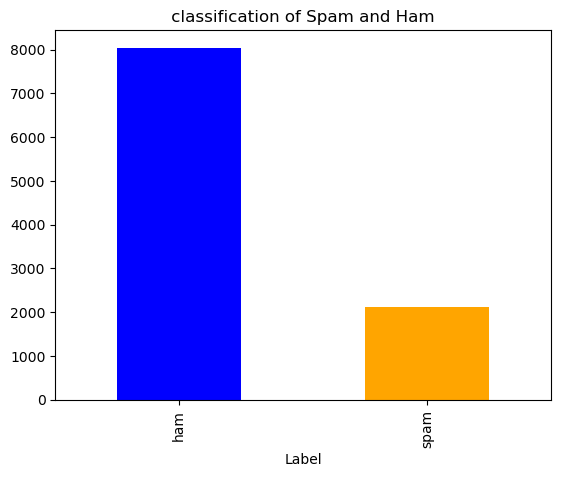

In [28]:
count_class = pd.value_counts(data['Label'],sort = True)
count_class.plot(kind='bar',color=["blue","orange"])
plt.title(" classification of Spam and Ham ")
plt.show()


####   So here is a Class Imblance in Data 

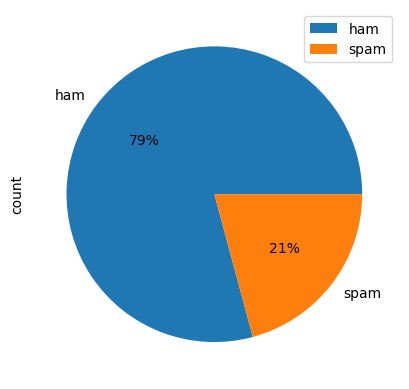

In [29]:
count_class.plot(kind = "pie",autopct = '%1.0f%%')
plt.legend()
plt.show()

# Text Analytics

In [30]:
count1 = Counter("".join(data[data['Label']=='ham']["Message"]).split()).most_common(20)
df1 = pd.DataFrame.from_dict(count1)
df1 = df1.rename(columns = {0:"words in non-spam",1:"count"})

count2 = Counter("".join(data[data['Label']=='spam']["Message"]).split()).most_common(20)
df2 = pd.DataFrame.from_dict(count1)
df2 = df2.rename(columns = {0:"words in spam",1:"count_"})

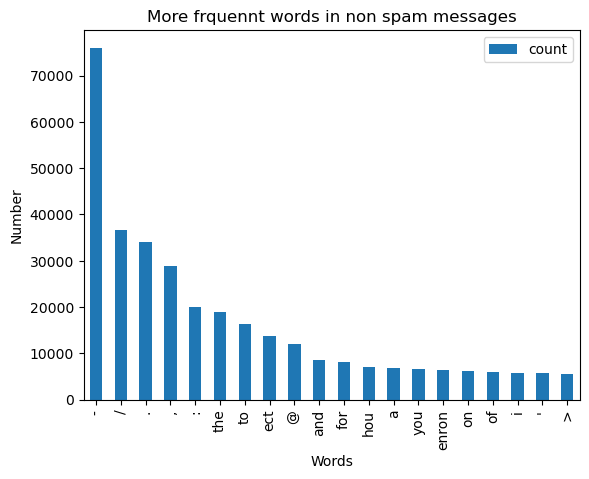

In [31]:
df1.plot.bar(legend = True)
y_pos = np.arange(len(df1["words in non-spam"]))
plt.xticks(y_pos,df1["words in non-spam"])
plt.title("More frquennt words in non spam messages")
plt.xlabel("Words")
plt.ylabel("Number")
plt.show()

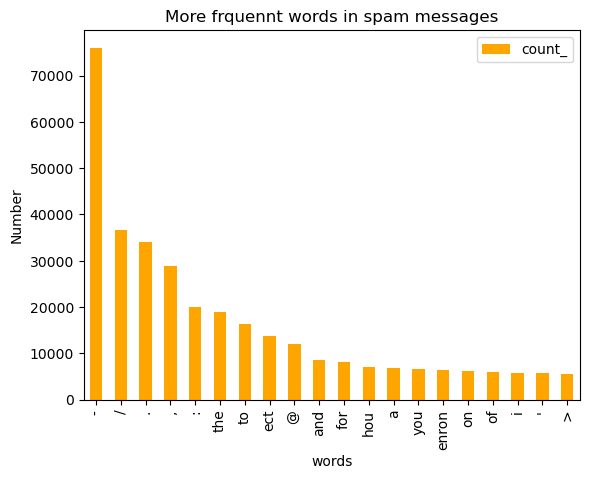

In [32]:
df2.plot.bar(legend = True , color='orange')
y_pos = np.arange(len(df2["words in spam"]))
plt.xticks(y_pos, df2["words in spam"])
plt.title("More frquennt words in spam messages")
plt.xlabel("words")
plt.ylabel("Number")
plt.show()

##### We can see that the majority of frequent words in both classes are stop words such as , \ . etc. and the article and perposition.

#### Remove the stop words

In [33]:
import nltk
import re

In [34]:
from nltk import word_tokenize
from nltk.corpus import stopwords

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize



In [35]:
data['Message'] = data['Message'].str.lower()
data['Message'] = data['Message'].str.replace(r'\W+',' ')
data['Message'] = data['Message'].str.replace(r'\s+',' ')
data['Message'] = data['Message'].str.strip()
data['Message'] = data['Message'].str.replace(r'\b\w\b','')
data['Message'] = data['Message'].str.replace(r'\b\w{1,2}\b','')

In [36]:
data.head()

,Label,Message
0,ham,subject: enron methanol ; meter # : 988291\nth...
1,ham,"subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"subject: photoshop , windows , office . cheap ..."
4,ham,subject: re : indian springs\nthis deal is to ...


In [37]:
stopwords = set(stopwords.words('english'))
ps = PorterStemmer()

def stemming(message):
    message = message.split()
    message = [ps.stem(word) for word in message if word not in stopwords]
    return ' '.join(message) 

In [38]:
lemmatizer = nltk.stem.WordNetLemmatizer() # reducing the word in root form 


def lemmatizining(message):
    message = message.split()
    message = [lemmatizer.lemmatize(word) for word in message if word not in stopwords]
    return ' '.join(message) 

##### Lemmatizing is more meaning ful then stemming

In [39]:
data['Message'] = data['Message'].apply(lemmatizining)
data.head()

,Label,Message
0,ham,subject: enron methanol ; meter # : 988291 fol...
1,ham,"subject: hpl nom january 9 , 2001 ( see attach..."
2,ham,"subject: neon retreat ho ho ho , ' around wond..."
3,spam,"subject: photoshop , window , office . cheap ...."
4,ham,subject: : indian spring deal book teco pvr re...


In [40]:
print(data['Message'][0].split())

['subject:', 'enron', 'methanol', ';', 'meter', '#', ':', '988291', 'follow', 'note', 'gave', 'monday', ',', '4', '/', '3', '/', '00', '{', 'preliminary', 'flow', 'data', 'provided', 'daren', '}', '.', 'please', 'override', 'pop', "'", 'daily', 'volume', '{', 'presently', 'zero', '}', 'reflect', 'daily', 'activity', 'obtain', 'gas', 'control', '.', 'change', 'needed', 'asap', 'economics', 'purpose', '.']


- Text preprocessing , tokenizing and filterning of stopwords are included in high level component that is able to build a dictionary of features and transform documents of features vectors

# Feature Engineering

#### **We remove the stop words in order to improve the analytics**

In [41]:
f = feature_extraction.text.CountVectorizer(stop_words ='english',lowercase = True)
x = f.fit_transform(data['Message']).toarray()
y = data['Label'].values
np.shape(x)

(10162, 51639)

##### We have created more than 51639 new features. 

In [42]:
x

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le



LabelEncoder()

In [44]:
y = le.fit_transform(y)
y

array([0, 0, 0, ..., 0, 0, 0])

In [45]:
pd.Series(y)

0        0
1        0
2        0
3        1
4        0
        ..
10157    1
10158    0
10159    0
10160    0
10161    0
Length: 10162, dtype: int32

### Predictive Analysis

- My goal is to predict if a new sms is spam or non-spam. I assusme that is much worse misclassify non-spam than misclassify as spam.(i don't want to have false positives)

   - The reason is because i normally don't check the spam message
#### The Two possible situations are :
   - 1. New spam sms in my inbox(false negative).
     #### Outcome : I delete it.
     2. New non-spam sms in my spam folder(false positives)
     #### Outcome: I probably don't read it

 **I Prefer the first option**

#### First we transform the varibale spam/ham into binary variable, then we split our data set into training set and test set

In [46]:
# i am using map function 
data['Label']= data['Label'].map({'spam':1,'ham':0})

In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)


In [48]:
x_train.shape , x_test.shape,y_train.shape,y_test.shape

((7113, 51639), (3049, 51639), (7113,), (3049,))

# Multinomial navie bayes Classifier

- we train different bayes models changing the regularization parameter alpha .

- We evalute the accuracy , recall & prcision of the model with the test set.

In [52]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

model = MultinomialNB()
model

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [53]:
model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [55]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 1, ..., 0, 1, 1])

In [59]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))

Accuracy Score: 0.9419481797310594
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96      2404
           1       0.81      0.95      0.87       645

    accuracy                           0.94      3049
   macro avg       0.90      0.95      0.92      3049
weighted avg       0.95      0.94      0.94      3049

Confusion Matrix: 
 [[2258  146]
 [  31  614]]


### This is good accurarcy result but it is a imblance data so it is just a glimpse of the model in model_training file i have blance the class 